In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
!pip install -q timm


In [16]:
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import matplotlib.pyplot as plt
import seaborn as sns


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [19]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [21]:
DATASET_PATH = "/kaggle/input/banknote/dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")


In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32   # 🔥 speed gain

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [23]:
train_data = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_data   = datasets.ImageFolder(VAL_DIR, transform=val_tfms)
test_data  = datasets.ImageFolder(TEST_DIR, transform=val_tfms)

class_names = train_data.classes
class_names


['counterfeit', 'genuine']

In [25]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [26]:
model = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=2
)

model = model.to(device)


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scaler = torch.cuda.amp.GradScaler()  # 🔥 AMP


/tmp/ipykernel_55/1800430012.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # 🔥 AMP


In [28]:
def train_one_epoch(model, loader, epoch):
    model.train()
    start_time = time.time()

    total_loss = 0
    preds, targets = [], []
    images_seen = 0
    last_print = time.time()

    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        images_seen += x.size(0)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds.extend(torch.argmax(out, 1).cpu().numpy())
        targets.extend(y.cpu().numpy())

        # 🔹 Print every ~1 minute
        if time.time() - last_print > 60:
            print(
                f"Epoch {epoch} | "
                f"Processed {images_seen} images | "
                f"Elapsed {int(time.time()-start_time)}s"
            )
            last_print = time.time()

    acc = accuracy_score(targets, preds)
    avg_loss = total_loss / len(loader)

    return avg_loss, acc, time.time() - start_time


In [29]:
def evaluate(model, loader):
    model.eval()
    losses, preds, targets = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            losses.append(loss.item())
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    return np.mean(losses), accuracy_score(targets, preds)


In [30]:
EPOCHS = 10
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, epoch_time = train_one_epoch(model, train_loader, epoch)
    val_loss, val_acc = evaluate(model, val_loader)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(
        f"\nEpoch [{epoch}/{EPOCHS}] "
        f"| Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Time: {epoch_time/60:.2f} min\n"
    )


/tmp/ipykernel_55/2989001974.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Processed 1568 images | Elapsed 60s
Epoch 1 | Processed 3104 images | Elapsed 122s
Epoch 1 | Processed 4832 images | Elapsed 184s
Epoch 1 | Processed 6432 images | Elapsed 246s

Epoch [1/10] | Train Loss: 0.2619, Train Acc: 0.8865 | Val Acc: 0.9664 | Time: 5.11 min



/tmp/ipykernel_55/2989001974.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2 | Processed 1536 images | Elapsed 60s
Epoch 2 | Processed 3200 images | Elapsed 120s
Epoch 2 | Processed 4832 images | Elapsed 181s
Epoch 2 | Processed 6496 images | Elapsed 242s

Epoch [2/10] | Train Loss: 0.0898, Train Acc: 0.9734 | Val Acc: 0.9935 | Time: 4.95 min



/tmp/ipykernel_55/2989001974.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8 | Processed 1632 images | Elapsed 60s
Epoch 8 | Processed 3296 images | Elapsed 120s
Epoch 8 | Processed 4960 images | Elapsed 182s
Epoch 8 | Processed 6624 images | Elapsed 243s

Epoch [8/10] | Train Loss: 0.0523, Train Acc: 0.9833 | Val Acc: 0.9984 | Time: 4.87 min



/tmp/ipykernel_55/2989001974.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9 | Processed 1600 images | Elapsed 60s
Epoch 9 | Processed 3296 images | Elapsed 121s
Epoch 9 | Processed 4960 images | Elapsed 181s
Epoch 9 | Processed 6656 images | Elapsed 243s

Epoch [9/10] | Train Loss: 0.0433, Train Acc: 0.9864 | Val Acc: 0.9935 | Time: 4.84 min



/tmp/ipykernel_55/2989001974.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10 | Processed 1696 images | Elapsed 60s
Epoch 10 | Processed 3360 images | Elapsed 122s
Epoch 10 | Processed 5024 images | Elapsed 183s
Epoch 10 | Processed 6752 images | Elapsed 244s

Epoch [10/10] | Train Loss: 0.0298, Train Acc: 0.9903 | Val Acc: 0.9730 | Time: 4.84 min



In [31]:
# Save final trained model
MODEL_PATH = "/kaggle/working/vit_banknote_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")


Model saved to /kaggle/working/vit_banknote_model.pth


In [33]:
print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

model.eval()

all_labels = []
all_preds = []
all_scores = []

criterion = torch.nn.CrossEntropyLoss()
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)[:, 1]   # class-1 probability
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_scores.extend(probs.cpu().numpy())

test_loss /= len(test_loader)



EVALUATING ON TEST SET


In [34]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_preds)

print("===== FINAL TEST RESULT =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")


===== FINAL TEST RESULT =====
Test Loss     : 0.0619
Test Accuracy : 97.88%


In [35]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_preds)

print("===== FINAL TEST RESULT =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")


===== FINAL TEST RESULT =====
Test Loss     : 0.0619
Test Accuracy : 97.88%


In [36]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1        = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

print("\n===== TEST PERFORMANCE (FINAL) =====")
print(f"Accuracy  : {test_accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-score  : {f1*100:.2f}%")
print(f"ROC-AUC   : {roc_auc*100:.2f}%")



===== TEST PERFORMANCE (FINAL) =====
Accuracy  : 97.88%
Precision : 97.94%
Recall    : 97.88%
F1-score  : 97.86%
ROC-AUC   : 99.65%


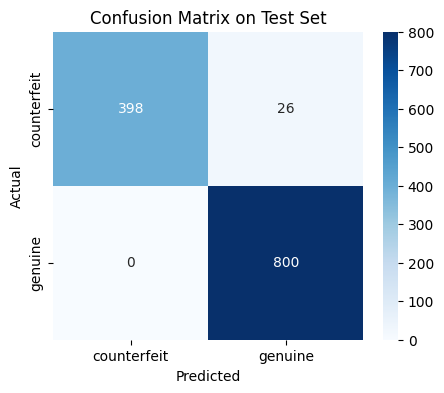

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix on Test Set")
plt.show()


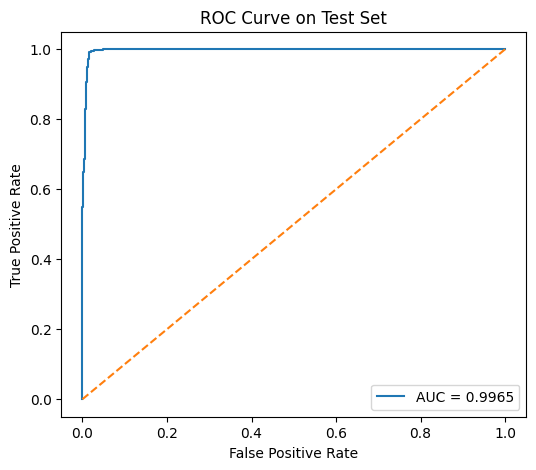

In [38]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()


In [39]:
import numpy as np

# Assume:
# counterfeit = 0
# genuine = 1

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

# APCER: Fake → Genuine
num_fake = np.sum(all_labels == 0)
apcer = np.sum((all_labels == 0) & (all_preds == 1)) / num_fake

# BPCER: Genuine → Fake
num_genuine = np.sum(all_labels == 1)
bpcer = np.sum((all_labels == 1) & (all_preds == 0)) / num_genuine

print("===== APCER / BPCER =====")
print(f"APCER (Fake → Genuine): {apcer*100:.2f}%")
print(f"BPCER (Genuine → Fake): {bpcer*100:.2f}%")


===== APCER / BPCER =====
APCER (Fake → Genuine): 6.13%
BPCER (Genuine → Fake): 0.00%


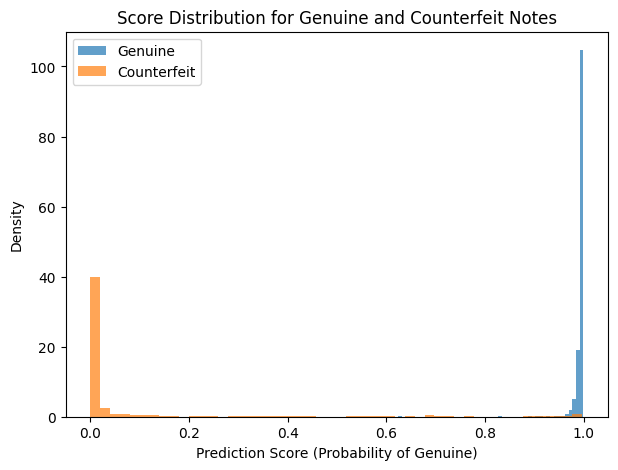

In [40]:
import matplotlib.pyplot as plt

genuine_scores = np.array(all_scores)[all_labels == 1]
counterfeit_scores = np.array(all_scores)[all_labels == 0]

plt.figure(figsize=(7,5))
plt.hist(genuine_scores, bins=50, alpha=0.7, label="Genuine", density=True)
plt.hist(counterfeit_scores, bins=50, alpha=0.7, label="Counterfeit", density=True)

plt.xlabel("Prediction Score (Probability of Genuine)")
plt.ylabel("Density")
plt.title("Score Distribution for Genuine and Counterfeit Notes")
plt.legend()
plt.show()


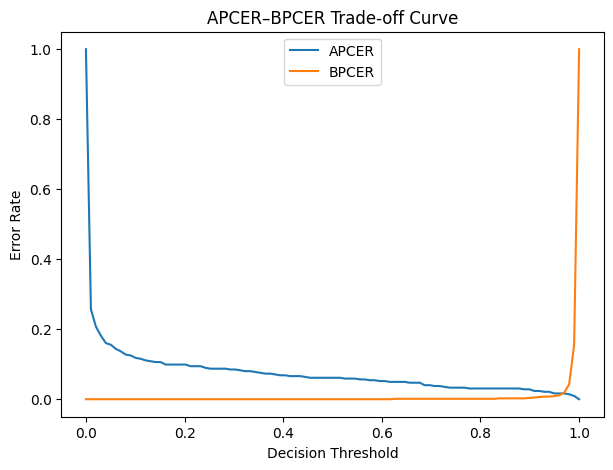

In [41]:
thresholds = np.linspace(0, 1, 100)
apcer_list = []
bpcer_list = []

for t in thresholds:
    preds_t = (np.array(all_scores) >= t).astype(int)

    apcer_t = np.sum((all_labels == 0) & (preds_t == 1)) / num_fake
    bpcer_t = np.sum((all_labels == 1) & (preds_t == 0)) / num_genuine

    apcer_list.append(apcer_t)
    bpcer_list.append(bpcer_t)

plt.figure(figsize=(7,5))
plt.plot(thresholds, apcer_list, label="APCER")
plt.plot(thresholds, bpcer_list, label="BPCER")
plt.xlabel("Decision Threshold")
plt.ylabel("Error Rate")
plt.title("APCER–BPCER Trade-off Curve")
plt.legend()
plt.show()
